# Introduction

In this notebook, we are going to perform analysis of heatwaves, their frequencies (or counts), durations and severities in monthly and yearly resolutions. We are going to perform analysis on 1958-2024 interval.

# Imports and Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import datetime

from src.plotting_utils import plot_time_slice, plot_with_time_range

In [2]:
temp_df = pd.read_csv('data/processed/temperature_1958_2024.csv',
    parse_dates=["datetime_utc"],
    index_col="datetime_utc"
)
temp_df["datetime_local"] = temp_df.index.tz_convert("Australia/Adelaide")
temp_df.head()

,temperature_2m,datetime_local,DMT,tmin,tmax,EHI_sig,EHI_accl,EHF,EHF_sev,severity
datetime_utc,,,,,,,,,,
1957-12-31 14:30:00+00:00,14.240001,1958-01-01 00:00:00+09:30,17.289999,12.79,21.789999,-8.070417,NaN,NaN,NaN,NaN
1957-12-31 15:30:00+00:00,14.390000,1958-01-01 01:00:00+09:30,17.289999,12.79,21.789999,-8.070417,NaN,NaN,NaN,NaN
1957-12-31 16:30:00+00:00,14.440001,1958-01-01 02:00:00+09:30,17.289999,12.79,21.789999,-8.070417,NaN,NaN,NaN,NaN
1957-12-31 17:30:00+00:00,14.490001,1958-01-01 03:00:00+09:30,17.289999,12.79,21.789999,-8.070417,NaN,NaN,NaN,NaN
1957-12-31 18:30:00+00:00,13.890000,1958-01-01 04:00:00+09:30,17.289999,12.79,21.789999,-8.070417,NaN,NaN,NaN,NaN


In [3]:
daily_df = temp_df.set_index('datetime_local').drop(columns=['temperature_2m', 'severity']).resample('D').mean()
severity = temp_df.set_index('datetime_local')['severity'].resample('D').max()
daily_df = daily_df.join(severity)
daily_df.head()

,DMT,tmin,tmax,EHI_sig,EHI_accl,EHF,EHF_sev,severity
datetime_local,,,,,,,,
1958-01-01 00:00:00+09:30,17.289999,12.790000,21.789999,-8.070417,NaN,NaN,NaN,NaN
1958-01-02 00:00:00+09:30,17.665000,12.440001,22.889999,-6.128750,NaN,NaN,NaN,NaN
1958-01-03 00:00:00+09:30,19.715000,14.690001,24.740000,-4.237084,NaN,NaN,NaN,NaN
1958-01-04 00:00:00+09:30,23.114999,16.689999,29.539999,-3.112084,NaN,NaN,NaN,NaN
1958-01-05 00:00:00+09:30,23.340000,15.640000,31.039999,-2.970417,NaN,NaN,NaN,NaN


We've downsampled our data to daily frequency. Because definiton of heatwave events is on daily frequency. `temperature_2m` is not relevant column anymore, `DMT` is represantative of it in daily frequency.

In [4]:
# Saving for later use.
daily_df.to_csv('data/processed/temp_daily_1958_2024.csv', index=True, index_label='datetime_local')

In [ ]:
# Loading cell 
daily_df = pd.read_csv('data/processed/temp_daily_1958_2024.csv', index_col='datetime_local')
daily_df.index = pd.to_datetime(daily_df.index, utc=True).tz_convert("Australia/Adelaide")
daily_df.head()

,DMT,tmin,tmax,EHI_sig,EHI_accl,EHF,EHF_sev,severity
datetime_local,,,,,,,,
1958-01-01 00:00:00+09:30,17.289999,12.790000,21.789999,-8.070417,NaN,NaN,NaN,NaN
1958-01-02 00:00:00+09:30,17.665000,12.440001,22.889999,-6.128750,NaN,NaN,NaN,NaN
1958-01-03 00:00:00+09:30,19.715000,14.690001,24.740000,-4.237084,NaN,NaN,NaN,NaN
1958-01-04 00:00:00+09:30,23.114999,16.689999,29.539999,-3.112084,NaN,NaN,NaN,NaN
1958-01-05 00:00:00+09:30,23.340000,15.640000,31.039999,-2.970417,NaN,NaN,NaN,NaN


----

In [4]:
daily_df.describe()

,DMT,tmin,tmax,EHI_sig,EHI_accl,EHF,EHF_sev
count,24472.000000,24472.000000,24472.000000,24472.000000,24442.000000,24442.000000,24442.000000
mean,16.543870,12.648125,20.439615,-9.749797,0.000077,-12.438976,0.018908
std,5.205036,4.419356,6.303175,4.850506,2.971615,9.758601,0.145403
min,5.465000,0.990000,8.740001,-19.670416,-9.606666,-57.172269,0.000000
25%,12.315001,9.490001,15.090000,-13.828749,-1.970000,-15.520416,0.000000
50%,15.789999,12.140000,19.340000,-10.337083,-0.317083,-12.351550,0.000000
75%,19.764999,15.090000,24.590000,-6.453750,1.632500,-8.012083,0.000000
max,37.887502,33.540001,42.737503,9.004582,16.121669,130.753481,4.650422


In [5]:
daily_df['severity'].value_counts(normalize=True)

severity
No-heatwave      0.963219
Low-intensity    0.031258
Severe           0.005319
Extreme          0.000205
Name: proportion, dtype: float64

In [8]:
print(f"1958-2024 interval heatwave prevalance:, {1-daily_df['severity'].value_counts(normalize=True)['No-heatwave']:.4f}.")

1958-2024 interval heatwave prevalance:, 0.0368.


As we can see, our events are very rare. 

In [ ]:
plot_with_time_range(daily_df, 'EHF')

![image](plot_img/04_ehf.png)

**!** Cell output is replaced with its image due to its size.

There is obvious yearly seasonality in EHF values, due to the fact that EHF value is directly related to temperature. Even at first quick glance, we can also see that the highest EHF value days have occurred from 2009 onward. These are **extreme** class heatwaves. 

In [7]:
# Heatwave days by definition.
heat_df = daily_df.loc[daily_df['EHF']>0]
print(f"Total heatwave days in 1958-2024 interval:", heat_df.shape[0])

Total heatwave days in 1958-2024 interval: 899


**!! Caution:** This is not the actual total duration by days. These are the days define heatwave events with together 2 consecutive days come after. We are going to check actual heatwave durations in a future section. However from now, we are going to call days with $EHF>0$ as heatwave days, and mostly focus our analysis on this.

# Monthly Analysis

It's obvious that events are not distributed evenly by months. We are going to check how heatwaves are distributed by months in 1958-2024 interval.

In [6]:
heat_months = pd.Series(heat_df.index.month_name())
month_names = [datetime.date(2024, i, 1).strftime('%B') for i in range(1, 13)]
heat_months = heat_months.value_counts().reindex(month_names)
heat_months

datetime_local
January      309.0
February     274.0
March        108.0
April          2.0
May            NaN
June           NaN
July           NaN
August         NaN
September      NaN
October        3.0
November      52.0
December     151.0
Name: count, dtype: float64

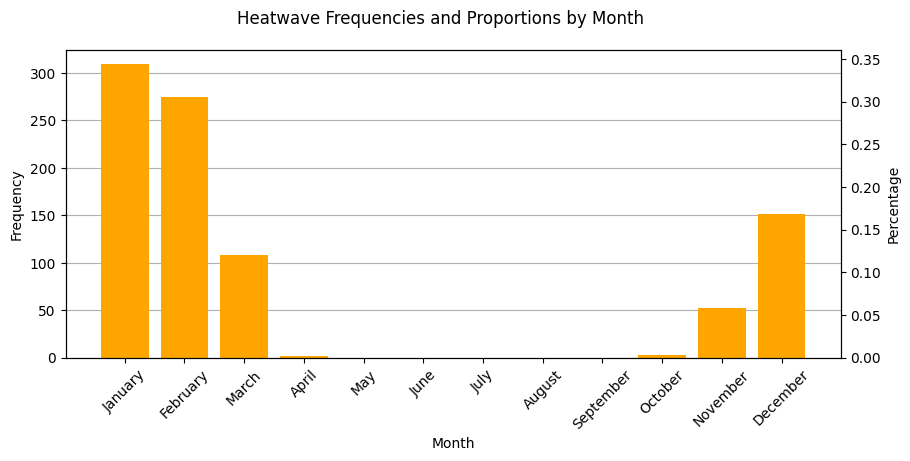

In [7]:
fig, ax1 = plt.subplots()
fig.set_size_inches(10, 4)
fig.suptitle('Heatwave Frequencies and Proportions by Month')

ax1.bar(heat_months.index, heat_months.values, color='orange', zorder=2)
ax1.set_xlabel('Month')
ax1.set_ylabel('Frequency')

ax2 = ax1.twinx()

ax2.bar(heat_months.index, (heat_months.values/heat_months.sum()), alpha=0)
ax2.set_ylabel('Percentage')

ax1.set_xticks(heat_months.index)
ax1.tick_params(axis='x', labelrotation=45)
ax1.grid(axis='y', which='both', alpha=1)

plt.show()

Heatwaves occurred mostly at mid-summer days: January and February. Specifically, they mostly occured in **January, February and December** in descending order. There is not any event in winter months. Consistent with physical laws.

Let's check severity distributions by months.

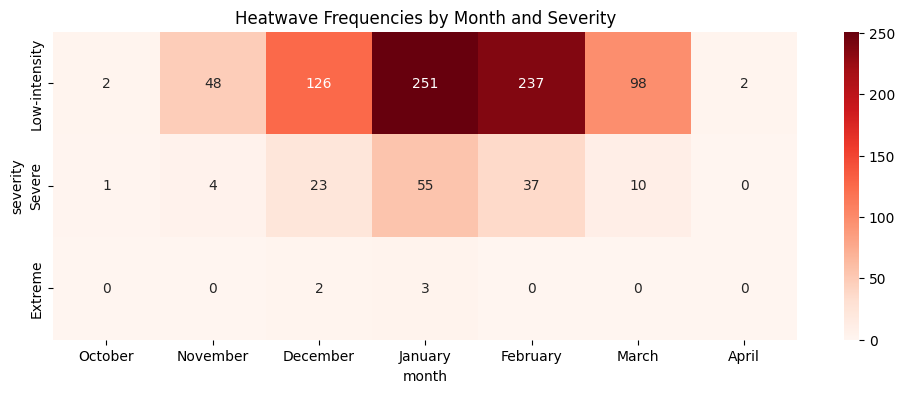

In [44]:
heat_df.loc[:,'month'] = heat_df.copy().index.month_name() # Taking copy to avoid warning.
month_sev_table = pd.crosstab(heat_df['month'], heat_df['severity'])
month_sev_table = month_sev_table[['Low-intensity', 'Severe', 'Extreme']]
month_sev_table = month_sev_table.reindex(month_names[-3:] + month_names[:4]) # Reordering months

plt.figure(figsize=(12, 4))
sns.heatmap(month_sev_table.T, annot=True, fmt="d", cmap="Reds")
plt.title("Heatwave Frequencies by Month and Severity")
plt.show()

Each severities monthly frequency orders align with total monthly frequency order. But, if we also check severity rates:

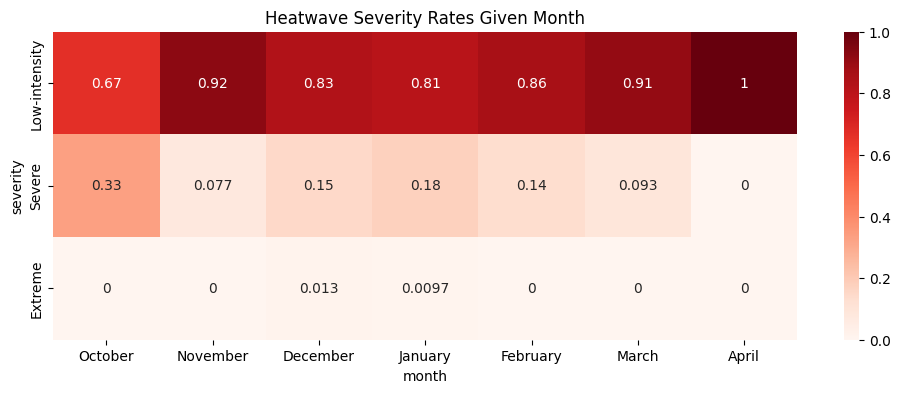

In [ ]:
month_severity_rate = month_sev_table.divide(month_sev_table.sum(axis=1), axis=0).round(4)
plt.figure(figsize=(12, 4))
sns.heatmap(month_severity_rate.T, annot=True,  cmap="Reds")
plt.title("Heatwave Severity Rates Given Month")
plt.show()

When we look at *severe and extreme heatwave rates of months*, we can see that highest rates in **January, December and February** in descending order. This is consistent with physical laws. Temperatures peak at mid-summer and gradually decrease. 
**!** We ignore *October* due to the fact that it has only 3 event instances in relevant time interval which is 1958-2024.

# Yearly Analysis

Every year different by either *frequencies, severity rates and actual event durations*. In this section, we are going to check them by through years. 

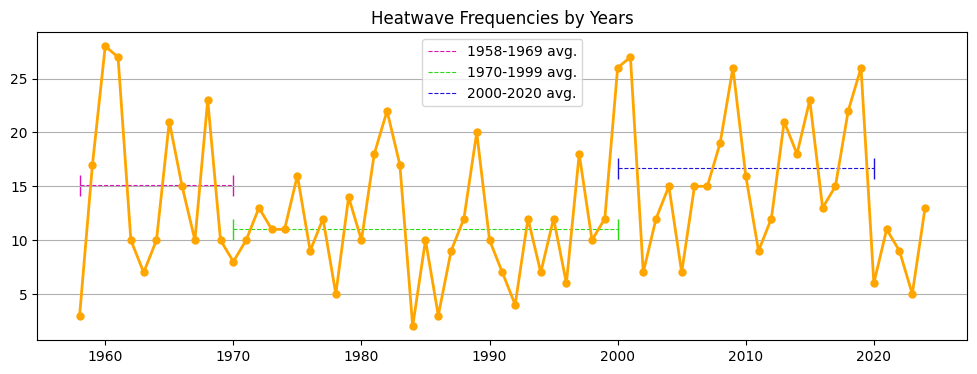

In [14]:
heat_df.loc[: ,'year'] = heat_df.copy().index.year # Adding year column
heat_years = heat_df['year'].value_counts()
heat_years = heat_years.sort_index()
# Interval means
mean_1958 = heat_years.loc[1958:1969].mean()
mean_1970 = heat_years.loc[1970:1999].mean()
mean_2000 = heat_years.loc[2000:2020].mean()
cap_size = 1

plt.figure(figsize=(12, 4))
plt.plot(heat_years.index, heat_years, color='orange', zorder=2, lw=2, marker='o', markersize=5)
plt.grid(axis='y', zorder=2)
# Mean lines
plt.hlines(mean_1958, xmin=1958, xmax=1970, color='#db12b6', zorder=1, lw=0.8, linestyle='--', label='1958-1969 avg.')
plt.vlines(x=[1958, 1970], ymin=mean_1958 - cap_size, ymax=mean_1958 + cap_size, colors='#db12b6', zorder=1, lw=1)
plt.hlines(mean_1970, xmin=1970, xmax=2000, color='#29db12', zorder=1, lw=0.8, linestyle='--', label='1970-1999 avg.')
plt.vlines(x=[1970, 2000], ymin=mean_1970 - cap_size, ymax=mean_1970 + cap_size, colors='#29db12', zorder=1, lw=1)
plt.hlines(mean_2000, xmin=2000, xmax=2020, color='#1f12db', zorder=1, lw=0.8, linestyle='--', label='2000-2020 avg.')
plt.vlines(x=[2000, 2020], ymin=mean_2000 - cap_size, ymax=mean_2000 + cap_size, colors='#1f12db', zorder=1, lw=1)
plt.legend()
plt.title('Heatwave Frequencies by Years')
plt.show()

By looking yearly heatwave frequencies, we can see that 1970-1999 frequencies are gathered at lower values compared to 1958-1969 and 2000-2020 intervals. We are going to test these hypothesis with an A/B tests in future sections in case of is there any significant statistical difference.

Also we can see a wave pattern, but not very clear. Roughly peaks every *7-8 years*. We can think these years as peaks: *1960, 1968, 1975, 1982, 1989, 1997, 2001, 2009, 2015, 2019.* Careful though, we should think peaks as here local peaks, not global. 

We ask that, *Is this peaks might have any relation with "El Nino Southern Oscilation (ENSO)"?*. To answer this question, we are going to check yearly **SOI** (Southern Oscillation Index) values taken from website of *Australian Government Bureau of Meteorology*: [Southern Oscillation Index (SOI) since 1876](https://www.bom.gov.au/climate/enso/soi/#). This data is in monthly frequency. We preprocessed it to yearly frequency by taking average of monthly values in notebook `extra_additional_data_fetch.ipynb`. Let's check it with our yearly heatwave frequencies.

In [75]:
# Yearly SOI from 1876 to present.
soi_yearly = pd.read_csv('data/processed/soi_yearly.csv', index_col='year') 
soi_yearly = soi_yearly.loc[1958:]

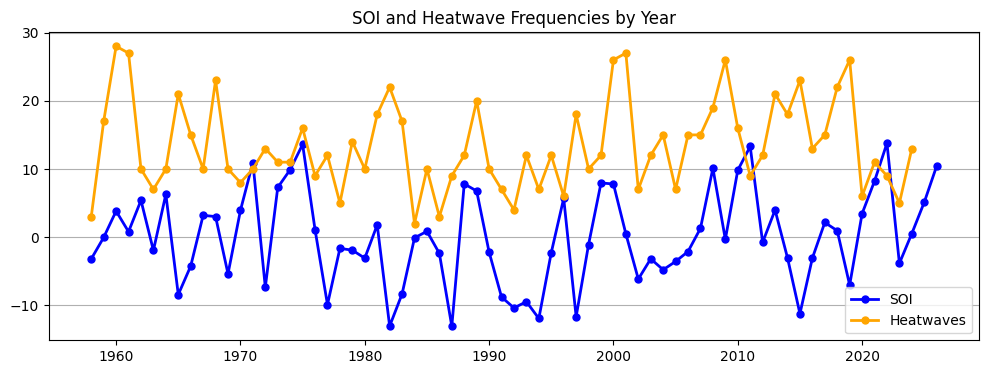

In [79]:
# Plot SOI and heatwave yearly frequencies
plt.figure(figsize=(12, 4))
plt.title('SOI and Heatwave Frequencies by Year')
plt.plot(soi_yearly.index, soi_yearly, color='b', zorder=2, lw=2, marker='o', markersize=5, label='SOI')
plt.plot(heat_years.index, heat_years, color='orange', zorder=2, lw=2, marker='o', markersize=5, label='Heatwaves')
plt.grid(axis='y', zorder=2)
plt.legend()
plt.show()

Some of the intervals those have greater than 0 SOI values match with peaks and high heatwave frequencies. Not clear evidence though.

**!!! Very Important DISCLAIMER About ENSO Index Part:** For this disclaimer, relevant project creator is called as *"I / me"*. During exploration and analysis process, I discovered the rough 7 years periodicity on `'Heatwave Frequencies by Years'` plot. Asked to *ChatGPT* that, is there a something known about this periodicity. It turned out it might be related about a climatic phenomenon **El Nino** and its **Southern Oscillation**. Term is not a thing I know other than that I've just heard about it once in the past in a *YouTube* video about oceanography and climatology. Neither, I am not an climate scientist or expert. Just, wanted to share a relevant information. 

In [83]:
year_sev_table = pd.crosstab(heat_df['year'], heat_df['severity'])
plot_with_time_range(df=year_sev_table, col_names=['Low-intensity', 'Severe', 'Extreme'], x_axis='index')

We can see 1958-1969, 1970-1999 and 2000-2020 intervals' yearly frequency overalll pattern in *Low-intensity* heatwave frequencies too. *Severe* heatwave frequency pattern is almost same through each three intervals, except we can see 4-5 years low key part on 1970-1980 interval. 

One of the most important thing in this severity frequency plot is **Extreme** heatwaves exist only in 2000-2020 interval. Also this interal slight bump on *Severe* heatwave frequencies, spesifically on 2004-2016 interval. We are going to check that if worst heatwaves in a year becomes worse in time, in future sections.

## A/B Tests for 1970-1999 and 2000-2020 Intervals

In this section, we spesifically test whether yearly heatwave frequencies are higher in 2000-2020 compared to 1970-1999, by using A/B tests.

In [113]:
from scipy.stats import ttest_ind

def ab_test(a, b, alternative='two-sided'): # Small function for convenience
    results = ttest_ind(a=a, b=b, equal_var=False, alternative=alternative) # Welch's t-test. 
    print(f"t-Stat: {results.statistic:.4f}")
    print(f"p-value: {results.pvalue:.4f}")

In [114]:
print("Yearly Heatwave Frequencies 1970-1999 vs 2000-2020")
ab_test(a=heat_years.loc[2000:2020], b=heat_years.loc[1970:1999], alternative='greater')

Yearly Heatwave Frequencies 1970-1999 vs 2000-2020
t-Stat: 3.3210
p-value: 0.0011


**!** Statistically very low p-value (0.001) shows that yearly heatwave counts are higher in 2000-2020 compared to 1970-1999.

We can validate this result with histograms and boxplots.

In [14]:
colors = ['#db12b6', '#1f12db']

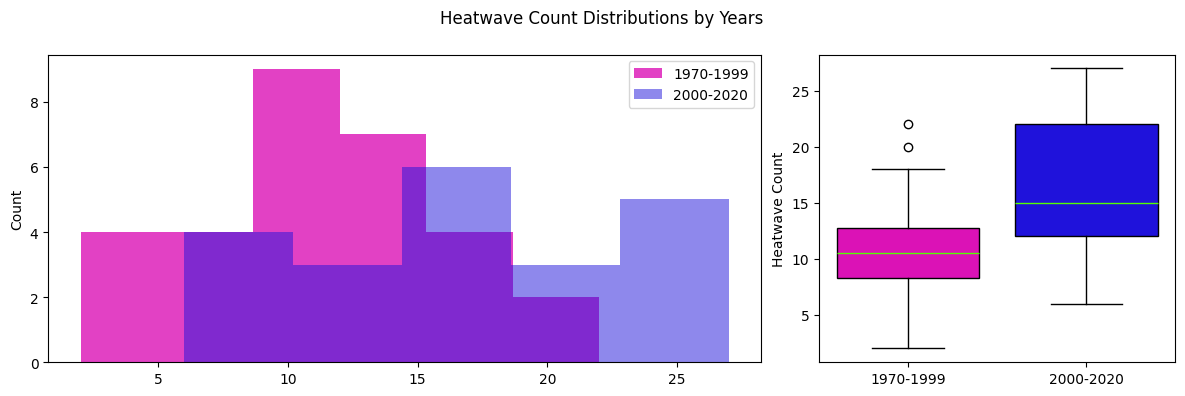

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})
fig.suptitle('Heatwave Count Distributions by Years')
fig.tight_layout()

ax[0].hist(heat_years.loc[1970:1999],  bins=6, alpha=0.8, label='1970-1999', color=colors[0])
ax[0].hist(heat_years.loc[2000:2020],  bins=5, alpha=0.5, label='2000-2020', color=colors[1])
ax[0].legend()
ax[0].set_ylabel('Count')

bp = ax[1].boxplot([heat_years.loc[1970:1999], heat_years.loc[2000:2020]], widths=0.8, 
                tick_labels=['1970-1999', '2000-2020'], patch_artist = True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

for median in bp['medians']:
    median.set(color="#55ff00")

ax[1].set_ylabel('Heatwave Count')
plt.show()

------

**A/B Test for EHFs between 1970-1999 and 2000-2020**

In [115]:
print("Yearly Heatwave EHF Means 1970-1999 vs 2000-2020")
ab_test(a=heat_df.loc['2000':'2020', 'EHF'], b=heat_df.loc['1970':'1999', 'EHF'], alternative='greater')

Yearly Heatwave EHF Means 1970-1999 vs 2000-2020
t-Stat: 0.9179
p-value: 0.1795


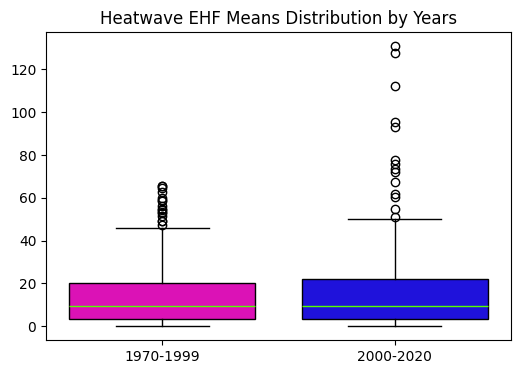

In [ ]:
plt.figure(figsize=(6, 4))
bp = plt.boxplot([heat_df.loc['1970':'1999', 'EHF'], heat_df.loc['2000':'2020', 'EHF']], widths=0.8, 
                tick_labels=['1970-1999', '2000-2020'], patch_artist = True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
for median in bp['medians']:
    median.set(color="#55ff00")

plt.title('Heatwave EHF Means Distribution by Years')
plt.show()

We tested EHF values of days heatwaves occured in 1970-1999 and 2000-2020. (`heat_df` contains only days heatwaves occured.) Neither there is no clear statisticall significance or visual evidence that show EHF distributions different for two interval of years. We can see that there are higher EHF values in 2000-2020 compared to 1970-1999. This happens most likely due to **Extreme** heatwaves occurred only years 2009, 2014 and 2019.

---

**!** One of the questions we've wondered above is, *"are worst heatwaves getting worse or not in time?"*. We can answer this question by checking yearly maximum EHF values.

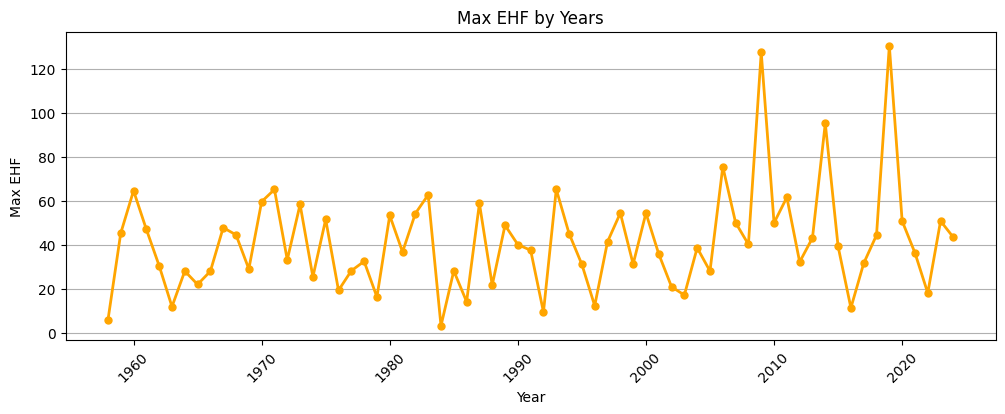

In [111]:
max_ehf_by_year = heat_df[['EHF', 'year']].groupby('year').max()

plt.figure(figsize=(12, 4))
plt.plot(max_ehf_by_year.index, max_ehf_by_year['EHF'], color='orange', zorder=2, lw=2, marker='o', markersize=5)
plt.grid(axis='y', zorder=1)
plt.title('Max EHF by Years')
plt.ylabel('Max EHF')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.show()

There is no overall increase in maximum EHF values over years. Only years with **extreme** heatwave events (2009, 2014, 2019) draw attention by their maximum EHF values. Let's check also statistically if there is an increase in maximum EHF values in 2000-2020 compared to 1958-1999. **! Careful**: We compare 1958-1999 with 2000-2020 here, not 1970-1999 with 2000-2020.

In [116]:
print("Max Heatwave EHFs 1958-1999 vs 2000-2020")
ab_test(a=max_ehf_by_year.loc[2000:2020, 'EHF'], b=max_ehf_by_year.loc[:1999, 'EHF'], alternative='greater')

Max Heatwave EHFs 1958-1999 vs 2000-2020
t-Stat: 1.9489
p-value: 0.0310


According to p-value if we use *0.05* level of significance, difference can be accepted statistically *significant*; else if we use *0.01* level of significance, difference can be accepted statistically *non-significant*. 
**!** But detail is, these are not samples of populations, like representatives of actual full data. More than that, these are populations themselves. We have all yearly possible data of intervals. Which means there is definitely an increase in maximum EHF values in 2000-2020 compared to 1958-1999.

# Duration Analysis

We are going to check the actual heatwave durations in this section. According to the definition, if an day instance has $EHF>0$, then that day and consecutive 2 days (totally 3 days) are exposed to a heatwave event. Eventually, $EHF>0$ instances / days (or rows) can be sequential or have 1 or 2 days gap. In thay case, there are one heatwave event that has duration more than 3 days. Now, we are going to do actual duration calculations by counting on that.

In [8]:
heat_dates = pd.DataFrame(data={'date': heat_df.index})
heat_dates['days_to_next'] = heat_dates.diff().shift(-1)
heat_dates
# Days till next heatwave from days EHF>0. In other words, gaps between EHF>0 rows.

,date,days_to_next
0,1958-02-07 00:00:00+09:30,7 days
1,1958-02-14 00:00:00+09:30,1 days
2,1958-02-15 00:00:00+09:30,322 days
3,1959-01-03 00:00:00+09:30,9 days
4,1959-01-12 00:00:00+09:30,3 days
...,...,...
894,2024-11-21 00:00:00+10:30,13 days
895,2024-12-04 00:00:00+10:30,9 days
896,2024-12-13 00:00:00+10:30,1 days
897,2024-12-14 00:00:00+10:30,1 days


In [9]:
durations = {'start_date':[heat_dates.iloc[0]['date']], 'end_date':[], 'duration':[]}
current_date = heat_dates.iloc[0]['date']

for i in range(heat_dates.shape[0]-1): # Last row's `days_to_next` is nan, hadle at the end.
    if heat_dates.iloc[i]['days_to_next'].days > 3: # 3 days threshold. 
        # Consecutive rows don't merge, because of gap more than 3 days.
        
        # 3 consecutive days with starting day (ith day) inclueded
        durations['end_date'].append(heat_dates.iloc[i]['date'] + pd.Timedelta(days=2)) 
        # Actual duration = end_date - start_date
        durations['duration'].append(durations['end_date'][-1] - durations['start_date'][-1] + pd.Timedelta(days=1))
        # Next row's start_date
        durations['start_date'].append(heat_dates.iloc[i+1]['date'])
    # else: pass

# Last is NaN. Handle separately.
durations['end_date'].append(heat_dates.iloc[-1]['date'] + pd.Timedelta(days=2)) 
durations['duration'].append(durations['end_date'][-1] - durations['start_date'][-1] + pd.Timedelta(days=1))
        
durations_df = pd.DataFrame(data=durations)

In [10]:
durations_df['duration'] = durations_df['duration'].dt.floor('D')

In [11]:
durations_df

,start_date,end_date,duration
0,1958-02-07 00:00:00+09:30,1958-02-09 00:00:00+09:30,3 days
1,1958-02-14 00:00:00+09:30,1958-02-17 00:00:00+09:30,4 days
2,1959-01-03 00:00:00+09:30,1959-01-05 00:00:00+09:30,3 days
3,1959-01-12 00:00:00+09:30,1959-01-19 00:00:00+09:30,8 days
4,1959-01-22 00:00:00+09:30,1959-01-25 00:00:00+09:30,4 days
...,...,...,...
312,2024-02-19 00:00:00+10:30,2024-02-21 00:00:00+10:30,3 days
313,2024-03-06 00:00:00+10:30,2024-03-13 00:00:00+10:30,8 days
314,2024-11-20 00:00:00+10:30,2024-11-23 00:00:00+10:30,4 days
315,2024-12-04 00:00:00+10:30,2024-12-06 00:00:00+10:30,3 days


There are total 317 actual heatwave events on 1958-2024 interval.

In [12]:
durations_df['duration'].describe()

count                          317
mean     4 days 21:34:38.233438485
std      2 days 02:36:08.284799365
min                3 days 00:00:00
25%                3 days 00:00:00
50%                4 days 00:00:00
75%                6 days 00:00:00
max               16 days 00:00:00
Name: duration, dtype: object

* Average duration of heatwaves: *4 days 21 hours 34 minutes*
* Maximum duration of heatwaves: *16 days*

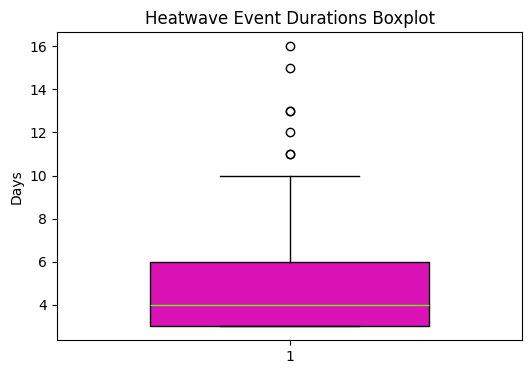

In [17]:
# Box plot
plt.figure(figsize=(6, 4))
bp = plt.boxplot(durations_df['duration'].dt.days, widths=0.6, patch_artist = True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
for median in bp['medians']:
    median.set(color="#55ff00")

plt.title('Heatwave Event Durations Boxplot')
plt.ylabel('Days')
plt.show()

* Half of them 3-4 days. 
* Almost whole upper half consist of 5-10 days.

In [23]:
dur_count = durations_df['duration'].value_counts().sort_index()
dur_rate = durations_df['duration'].value_counts(normalize=True).sort_index()

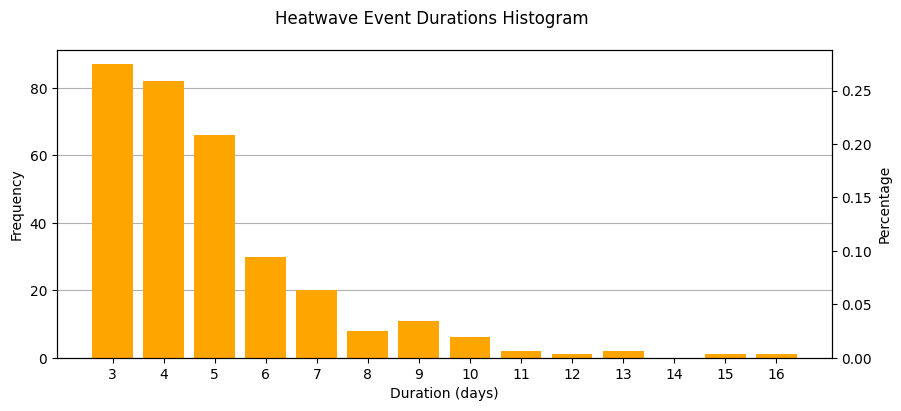

In [24]:
fig, ax1 = plt.subplots()
fig.set_size_inches(10, 4)
fig.suptitle('Heatwave Event Durations Histogram')

ax1.bar(dur_count.index.days, dur_count, color='orange', zorder=2)
ax1.set_ylabel('Frequency')
ax1.set_xlabel('Duration (days)')
ax1.set_xticks(range(3, 17))
ax1.grid(axis='y', which='both', alpha=1)

ax2 = ax1.twinx()
ax2.bar(dur_rate.index.days, dur_rate, alpha=0)
ax2.set_ylabel('Percentage')
plt.show()

As we can see, most of heatwave durations gathered at 3, 4 and 5 days. After 5 days, durations decrease quickly. 

Let's check the longest two events. 15 days and 16 days. 

In [19]:
# Starting and ending dates
durations_df[durations_df['duration'].dt.days >= 15]

,start_date,end_date,duration
232,2008-03-03 00:00:00+10:30,2008-03-18 00:00:00+10:30,16 days
233,2009-01-25 00:00:00+10:30,2009-02-08 00:00:00+10:30,15 days


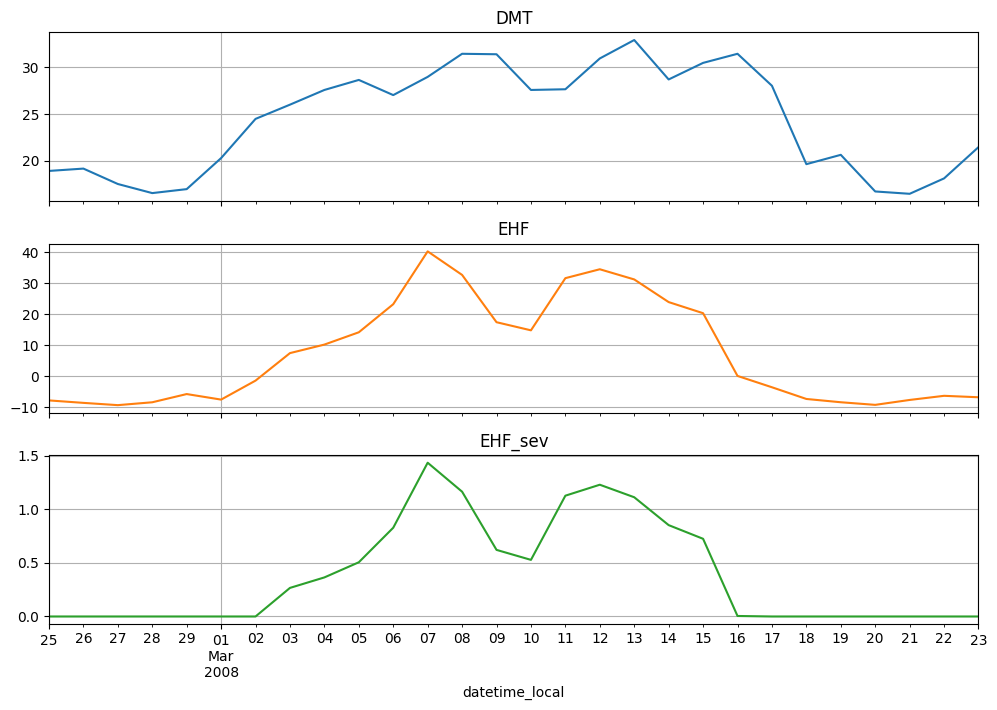

In [4]:
plot_time_slice(daily_df, '2008-02-25 00:00:00+10:30', '2008-03-23 00:00:00+10:30', 
                ['DMT', 'EHF', 'EHF_sev'], subplots=True)

This event ocurred between *2008-03-03 and 2008-03-18*, which is 16 days. Event continued at *Low-intensity* severity in general. It peaked at *Severe* severity on *2008-03-07* and *2008-03-12*.

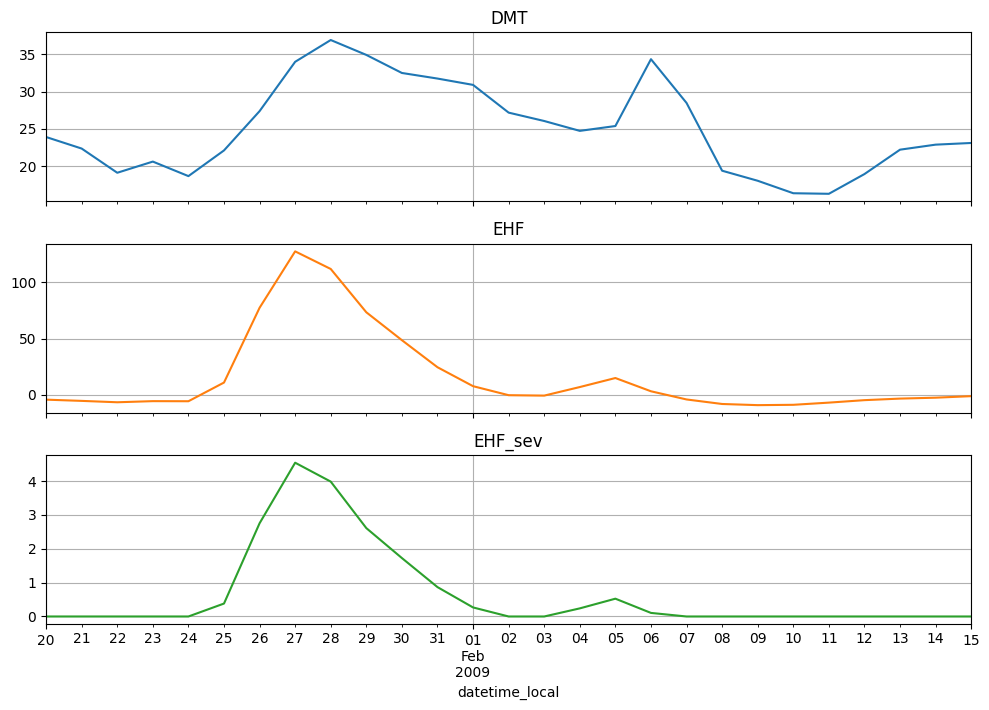

In [5]:
plot_time_slice(daily_df, '2009-01-20 00:00:00+10:30', '2009-02-15 00:00:00+10:30', 
                ['DMT', 'EHF', 'EHF_sev'], subplots=True)

This event ocurred between *2008-01-25 and 2008-02-08*, which is 15 days. This is one of the **extreme** heathwaves those rarely occured. From January 26 to January 30, event severity was **Extreme**. ($EHF_{sev}\geq3$ on January 28, which means that day and consecutive 2 days are exposed to a heatwave event according to definition.)

## Yearly Heatwave Durations

Let's check how heatwave durations vary by years. We can check this by mean and maximum durations.

In [25]:
duration_means_by_year = durations_df.groupby(durations_df['start_date'].dt.year)['duration'].mean()
duration_max_by_year = durations_df.groupby(durations_df['start_date'].dt.year)['duration'].max()

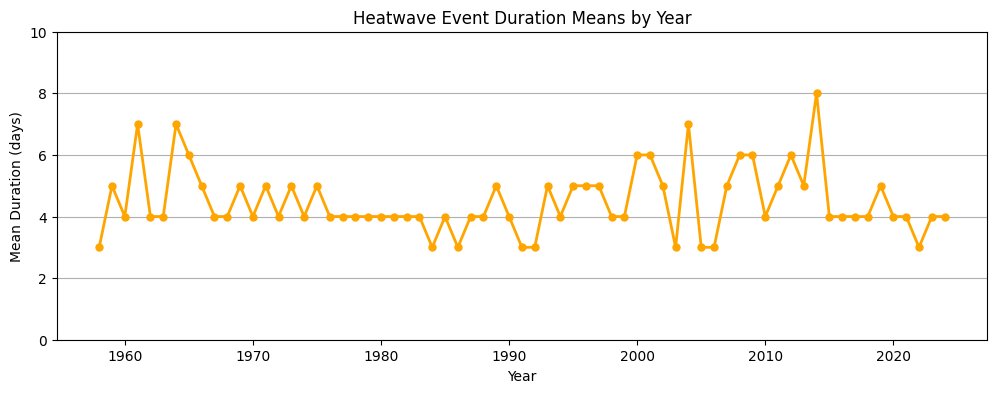

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(duration_means_by_year.index, duration_means_by_year.dt.days, color='orange', zorder=2, lw=2, marker='o', markersize=5)
plt.grid(axis='y', zorder=2)

plt.ylim(0, 10)
plt.xlabel('Year')
plt.ylabel('Mean Duration (days)')
plt.title('Heatwave Event Duration Means by Year')
plt.show()

We can see that 1958-1969, 1970-1999 and 2000-2020 intervals' *Frequency by Years* match with durations too. 2000-2020 interval duration means are highest, then 1970-1999, and finally 1958-1969. (In descending order.) 

Let's check  1970-1999 and 2000-2020 intervals with A/B test.

In [144]:
print("Event Duration Means by Year: 1970-1999 vs 2000-2020")
ab_test(a=duration_means_by_year.loc[2000:2020].dt.days,
        b=duration_means_by_year.loc[1970:1999].dt.days,
        alternative='greater')

Event Duration Means by Year: 1970-1999 vs 2000-2020
t-Stat: 2.4587
p-value: 0.0104


Statistically significant p-value (0.01) shows that 2000-2020 heatwave durations are higher than 1970-1999 heatwave durations. Let's display intervals' boxplots.

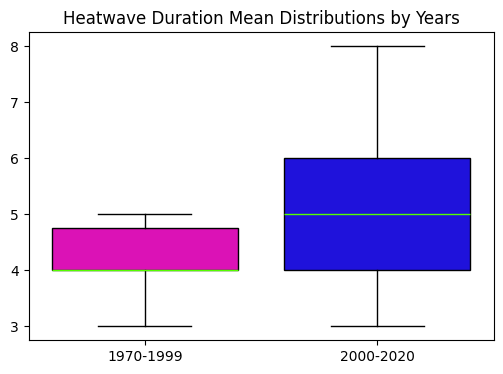

In [ ]:
plt.figure(figsize=(6, 4))
plt.title('Heatwave Duration Mean Distributions by Years')
bp = plt.boxplot([duration_means_by_year.loc[1970:1999].dt.days, duration_means_by_year.loc[2000:2020].dt.days], widths=0.8, 
                tick_labels=['1970-1999', '2000-2020'], patch_artist = True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
for median in bp['medians']:
    median.set(color="#55ff00")

ax[1].set_ylabel('Heatwave Count')
plt.show()

---
**Maximum Heatwave Durations by Years**

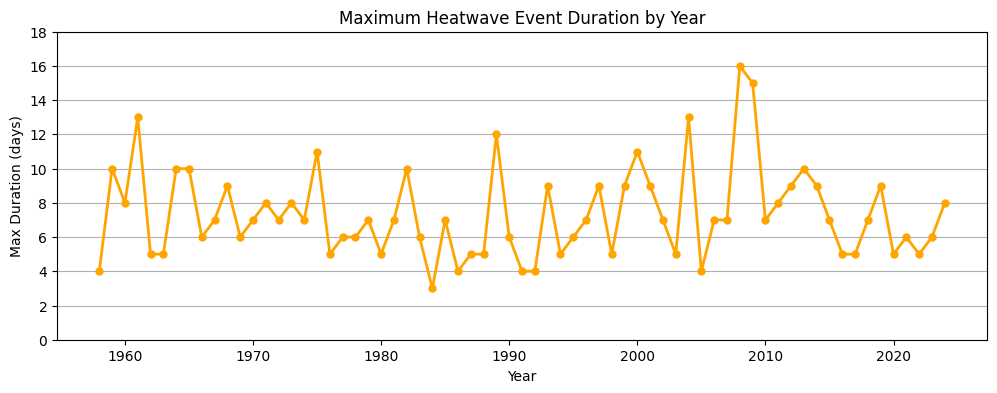

In [152]:
plt.figure(figsize=(12, 4))
plt.plot(duration_max_by_year.index, duration_max_by_year.dt.days, color='orange', zorder=2, lw=2, marker='o', markersize=5)
plt.grid(axis='y', zorder=2)
plt.ylim(0, 18)
plt.xlabel('Year')
plt.ylabel('Max Duration (days)')
plt.title('Maximum Heatwave Event Duration by Year')
plt.show()

In [154]:
print("Maximum Event Duration by Year: 1970-1999 vs 2000-2020")
ab_test(a=duration_max_by_year.loc[2000:2020].dt.days,
        b=duration_max_by_year.loc[1970:1999].dt.days,
        alternative='greater')

Maximum Event Duration by Year: 1970-1999 vs 2000-2020
t-Stat: 2.0608
p-value: 0.0238


It seems, maximum durations are not seperated as much as frequencies or mean durations are, for 3 year intervals: 1958-1999, 1970-1999 and 2000-2020. But still, between 1970-1999 and 2000-2020, statistically difference exists with 0.023 p-value.

# Outro and Conclusion

As last word we can say that: Heatwave frequencies and durations are higher, also worst heatwaves (max EHF events of years) are got worsen in 2000-2020 time interval compared to 1970-1999.  

# Bottom